# Archivo para calcular rentabilidad de un portafolio

In [167]:
##### Modulos necesarios
import pandas as pd
import numpy as np
from tqdm import tqdm
import scipy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Rentabilidad equilibrada

Por varias razones, una rentabilidad equilibrada es necesaria para medir diferences mas equitativamente. La formula es

$R_t = \sum_i^n \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-1}} * w_{i,t-1} * r_{i,t} - C*\sum_i^n | \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-1}} * w_{i,t-1} - \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-2}} * w_{i,t-2} |$

Los requisitos para calcular esta rentabilidad son:
- Rendimientos: $r_{i,t}$
- Pesas del portafolio: $w_{i,t}$
- Exponentially Weighted Moving Standar Deviation (EWMSD): $\tilde{\sigma}_{i,t-1}$
- Constantes - volatilidad deseada $\sigma_{tgt}$ y costo de transacciones $C$

El EWMA generalmente se calcula en la siguiente manera:

$\text{EWMA}_t(x) = \alpha * x_t + (1-\alpha) * \text{EWMA}_{t-1}(x)$

Implicando que el EWMSD es:

$\tilde{\sigma}_{i,t} = \sqrt{\alpha(r_t-\mu_{t-1})^2 + (1-\alpha)\tilde{\sigma}_{t-1}^2}$


In [161]:
##### Creando datos necesarios
#### Rendimientos
df_rendis = pd.read_csv('retornos.csv', index_col='Date')


#### Nombre de las 32 empresas
empresas = df_rendis.columns.to_list()

#### Calculando EWMSD
for name in empresas:
    df_rendis[f'EWMSD.{name}'] = df_rendis[name].ewm(span=30, adjust=False).std()
    # df_rendis[f'EWMSD.{name}']  = [1] * df_rendis.shape[0]    #Debug
    # df_rendis[f'Posicion.{name}'] = [1] * df_rendis.shape[0]  #Posiciones falsas para debug
    # df_rendis[f'Rentabilidad.{name}'] = df_rendis[name] * (1/df_rendis[f'EWMSD.{name}'].shift(1))  *df_rendis[f'Posicion.{name}'].shift(1) - \
    # 1*abs(((1/df_rendis[f'EWMSD.{name}'].shift(1))*df_rendis[f'Posicion.{name}'].shift(1)) - ((1/df_rendis[f'EWMSD.{name}'].shift(2))*df_rendis[f'Posicion.{name}'].shift(2)))
    #     #Simulando rentabilidad calculacion

#### Eliminando datos
### Al crear la particion de los datos
    # Bajo "matlab_procesamiento", no se completo el ultimo conjunto porque solo tenia 62
            # dias y le faltaban 160 mas
df_rendis = df_rendis.iloc[:-62]
### Al separar los datos en train/val/test
    # El trainset tiene 252 dias y el valset tiene 63
    # Adicionalmente, los siguiente 30 dias no se consideran porque se utilizaron para
            # crear la primera ventana del testset
    # Entonces los primeros 252 + 63 + 30 = 345 dias se eliminan
df_rendis = df_rendis.iloc[345:]



In [162]:
##### Integrando datos de MATLAB a previos datos
#### Extrayendo los datos de matlab archivos
df_sliding_final_preds = pd.DataFrame()
for i in tqdm(range(22)):
    tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
    df_tmp = pd.DataFrame(tmp['Ypred_final'])
    df_sliding_final_preds = pd.concat([df_sliding_final_preds, df_tmp], axis=0, ignore_index=True)
del tmp

#### Cambiando nombres e index de dataframe extraido
df_sliding_final_preds.columns = [f'Posicion.{nom}' for nom in empresas]
df_sliding_final_preds.index = df_rendis.index

#### Sumando la cantidad de posiciones positivas
    # Las posiciones finales va a ser divido equitativamente entre todas 
            # las empresas que el modelo predicio hiba a tener meyor rendimiento
suma = df_sliding_final_preds.sum(axis=1)

#### Asignando las posiciones equitativamente
df_sliding_posiciones = df_sliding_final_preds.div(suma, axis=0)

#### Integrando posiciones con rendimientos
df_sliding = pd.concat([df_rendis, df_sliding_posiciones], axis=1, ignore_index=False)

# display(df_sliding.head())


100%|██████████| 22/22 [00:00<00:00, 720.05it/s]


In [163]:
##### Calculando rentabilidad del portafolio
#### Hiperparametros
tgt = 0.1
costo = 0.00001

#### Calculando rentabilidad equitativa
df_sliding_rentabilidad = pd.DataFrame()
for name in empresas:
    df_sliding_rentabilidad[f'Rentabilidad.{name}'] = df_sliding[name] * (tgt/df_sliding[f'EWMSD.{name}'].shift(1))  * df_sliding[f'Posicion.{name}'].shift(1) - \
    costo*abs(((tgt/df_sliding[f'EWMSD.{name}'].shift(1))*df_sliding[f'Posicion.{name}'].shift(1)) - ((tgt/df_sliding[f'EWMSD.{name}'].shift(2))*df_sliding[f'Posicion.{name}'].shift(2)))

#### Elimando primera dos fila por el "shift(2)"
df_sliding_rentabilidad = df_sliding_rentabilidad.iloc[2:]

#### Calculando la suma de rendimientos de cada accion
sliding_rentabilidad_diaria = df_sliding_rentabilidad.sum(axis=1)





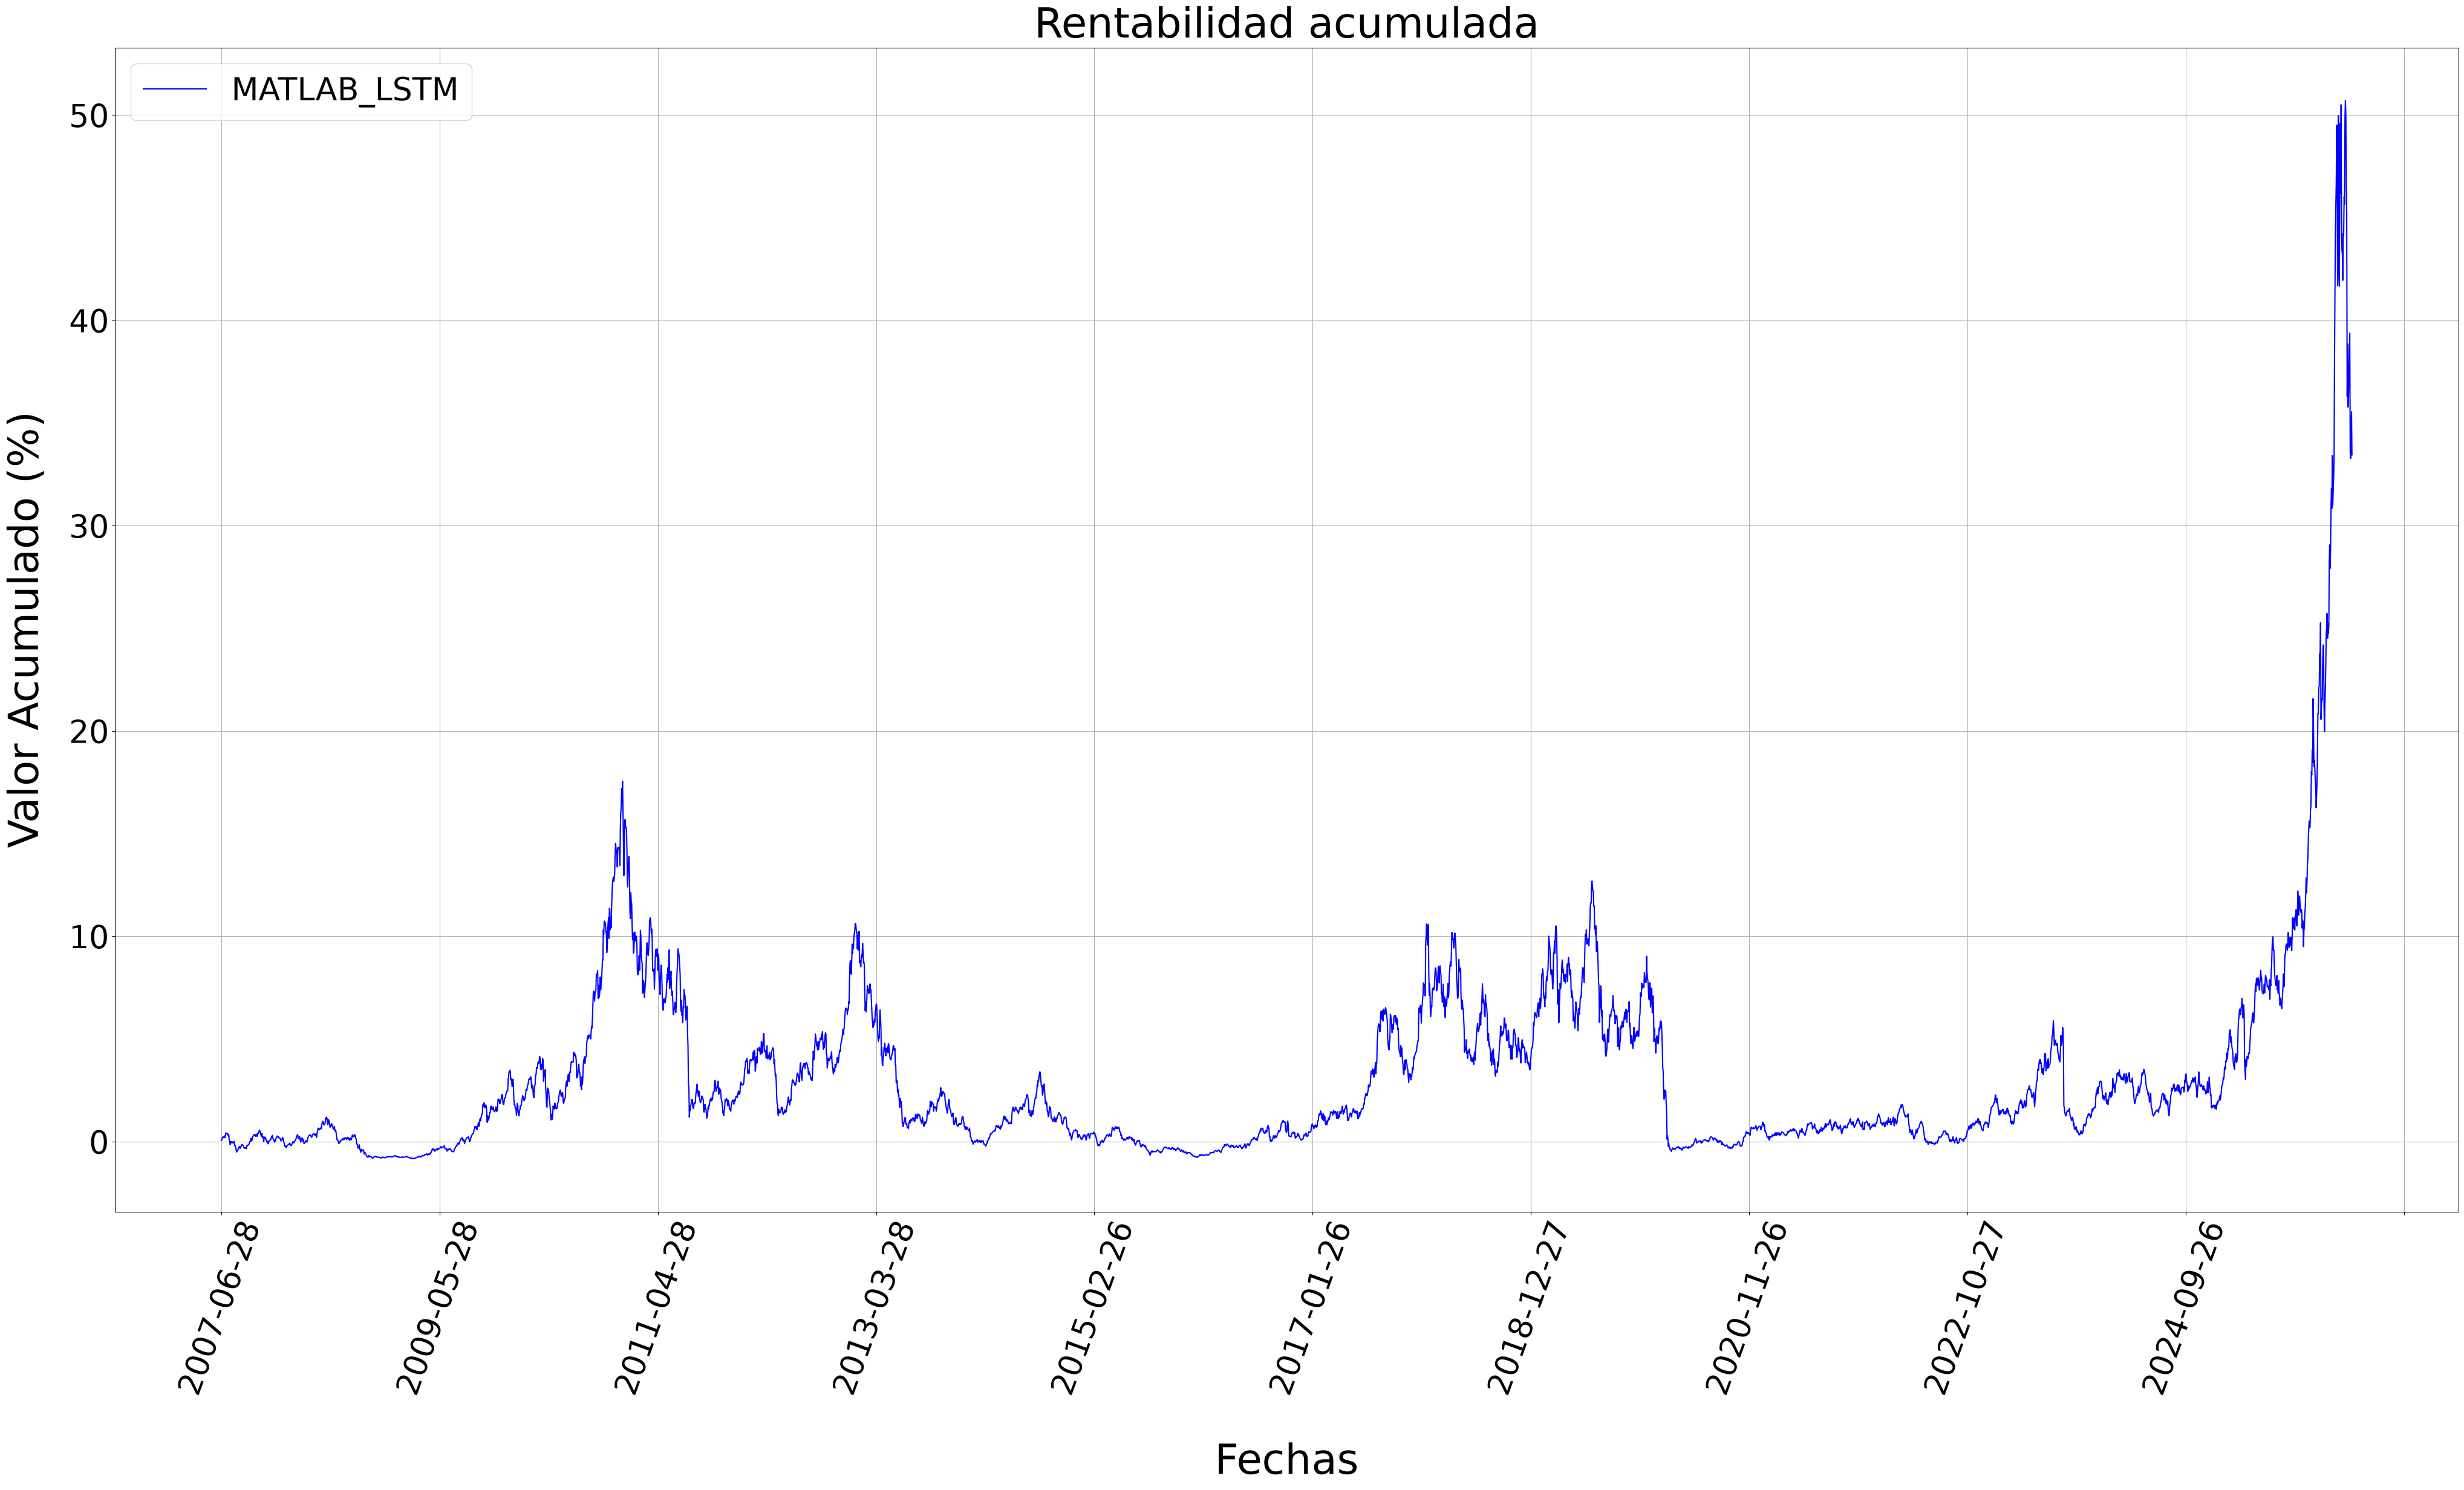

In [174]:
##### Calculando y trazando rentabilidad acumulada
#### Calculacion
sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1

#### Grafo
SALTO_X = 500
ANCHURA = 50
ALTURA = 25

fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

ax.plot(
    sliding_rentabilidad_acumulada.index,
    sliding_rentabilidad_acumulada,
    color='blue',
    label = 'MATLAB_LSTM',
    linestyle = 'solid'
)



ax.set_title('Rentabilidad acumulada',fontsize = ANCHURA)
ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
ax.legend(fontsize = 0.75*ANCHURA)
ax.grid(True)

plt.show()





In [ ]:
# DataFrame original
# df = pd.DataFrame({
#     'Nombre': ['Ana', 'Luis'],
#     'Edad': [25, 30]
# })

# print("DataFrame original:")
# print(df)

# # Nuevas filas como otro DataFrame
# nuevas_filas = pd.DataFrame({
#     'Nombre': ['María', 'Pedro'],
#     'Edad': [28, 35]
# })

# # Agregar usando pd.concat
# df = pd.concat([df, nuevas_filas], ignore_index=True)

# print("\nDataFrame después de agregar filas:")
# print(df)






# # Crear un ndarray de ejemplo (matriz de 3x3)
# array = np.array([[1, 2, 3],
#                   [4, 5, 6],
#                   [7, 8, 9]])

# # Convertir el ndarray a DataFrame sin nombres de columnas explícitos
# df_simple = pd.DataFrame(array)

# # Mostrar el DataFrame
# print("DataFrame simple:\n", df_simple)

# # Convertir el ndarray a DataFrame con nombres de columnas personalizados
# columnas = ['A', 'B', 'C']
# df_named = pd.DataFrame(array, columns=columnas)

# # Mostrar el DataFrame con nombres de columnas
# print("DataFrame con columnas nombradas:\n", df_named)

# # Convertir un ndarray con tipos de datos mixtos
# array_mixto = np.array([[1, 'manzana', 3.5],
#                         [2, 'pera', 4.0],
#                         [3, 'banana', 2.8]], dtype=object)

# df_mixto = pd.DataFrame(array_mixto, columns=['ID', 'Fruta', 'Precio'])
# print("DataFrame con tipos mixtos:\n", df_mixto)

In [ ]:
# ##### DEBUG ---- Creando datos necesarios
# #### Rendimientos
# df_rendis = pd.read_csv('retornos.csv', index_col='Date')

# empresas = df_rendis.columns.to_list()
# print(empresas)
# sums = df_rendis.sum(axis=1)
# display(sums)

# #### EWMSD
# # df = pd.DataFrame({'valor': [10, 20, 15, 25, 30]})
# # resultado = df.ewm(span=30, adjust=False).std()

# for name in df_rendis.columns:
#     # df_rendis[f'EWMSD.{name}'] = df_rendis[name].ewm(span=30, adjust=False).std()   # Verdadero
#     df_rendis[f'EWMSD.{name}']  = [1] * df_rendis.shape[0]  #Debug
#     df_rendis[f'Posicion.{name}'] = [1] * df_rendis.shape[0]  #Debug

# # display(df_rendis.head())

# #Form 1
# form1 = pd.DataFrame(index=df_rendis.index)
# # for name in empresas:
# #     form1[name] = df_rendis[name]*df_rendis[f'Posicion.{name}'].shift(2)

# # display(form1.sum(axis=1))

# # Form 2
# # for name in empresas:
# #     form1[name] = df_rendis[name] * (0.1/df_rendis[f'EWMSD.{name}'].shift(3))  *df_rendis[f'Posicion.{name}'].shift(2)


# # display(form1.sum(axis=1))


# # Form 4
# for name in empresas:
#     form1[name] = df_rendis[name] * (1/df_rendis[f'EWMSD.{name}'].shift(1))  *df_rendis[f'Posicion.{name}'].shift(1) - \
#     1*abs(((1/df_rendis[f'EWMSD.{name}'].shift(1))*df_rendis[f'Posicion.{name}'].shift(1)) - ((1/df_rendis[f'EWMSD.{name}'].shift(2))*df_rendis[f'Posicion.{name}'].shift(2)))

# display(form1.sum(axis=1))
